In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src_model.config import (
    input_path,
    train_path_v2,
    test_path_v2,
    feature_meta_path_v2,
    comparison_path_v2,
    model_dir,
    target_col,
    train_year,
    test_year,
    forbidden_cols,
    always_drop_v2,
    categorical_cols_v2
)
from src_model.feature_engineering_v2 import run_feature_engineering_v2
from src_model.training_v2 import (
    train_all_models,
    load_model_ready_data,
    get_model_zoo
)
from src_model.testing_v2 import (
    evaluate_on_test,
    evaluate_all_saved_models,
    predict_test
)
from src_model.comparing_v2 import (
    run_full_comparison,
    summary_report,
    collect_feature_importances
)
from src_model.utils import load_json

sns.set_theme(style = 'whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

print('ROOT:', ROOT)
print('input:', input_path)
print('train years:', train_year, '| test year:', test_year)
print('forbidden:', forbidden_cols)
print('always_drop:', always_drop_v2)
print('categorical:', categorical_cols_v2)

ROOT: E:\AI study\HDB_resale_market_analysis
input: E:\AI study\HDB_resale_market_analysis\src_model\..\data\aid\resale_trx_geo.csv
train years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025] | test year: 2026
forbidden: {'resale_price', 'price_per_sqm'}
always_drop: {'search_val', 'flat_year', 'status'}
categorical: {'flat_type', 'flat_model', 'subzone', 'postal', 'blk', 'st', 'nearest_mrt', 'zone_id'}


In [2]:
fe = run_feature_engineering_v2()
print('n_train:', fe['meta']['n_train'])
print('n_test:', fe['meta']['n_test'])
print('n_features:', len(fe['feature_columns']))
print('\nFeature columns:')
print(fe['feature_columns'])
must_absent = ['price_per_sqm', 'status', 'search_val']
must_absent += list(always_drop_v2)
bad = [c for c in must_absent if c in fe['feature_columns']]
print('\nShould be absent (empty = OK):', bad)
mrt_like = [c for c in fe['feature_columns'] if 'mrt' in c.lower()]
print('MRT-related kept:', mrt_like)
fe['X_train'].dtypes

2026-09-14 02:28:38 | INFO     | src_model.feature_engineering_v2 | Loading E:\AI study\HDB_resale_market_analysis\src_model\..\data\aid\resale_trx_geo.csv ...
2026-09-14 02:28:39 | INFO     | src_model.feature_engineering_v2 | Loaded shape: (239265, 26)
2026-09-14 02:28:39 | INFO     | src_model.feature_engineering_v2 | Dropped 0 rows with missing target
2026-09-14 02:28:40 | INFO     | src_model.feature_engineering_v2 | Selected 21 feature columns
2026-09-14 02:28:40 | INFO     | src_model.feature_engineering_v2 | Parsed string column: lease_commence
2026-09-14 02:28:40 | INFO     | src_model.feature_engineering_v2 | Parsed string column: remaining_lease_month
2026-09-14 02:28:40 | INFO     | src_model.feature_engineering_v2 | Temporal split -> train: 221758 (2017-2025), test: 17507 (year = 2026)
2026-09-14 02:28:43 | INFO     | src_model.feature_engineering_v2 | Saved train -> E:\AI study\HDB_resale_market_analysis\src_model\..\data\model_based\train_v2.csv
2026-09-14 02:28:43 | INF

n_train: 221758
n_test: 17507
n_features: 21

Feature columns:
['trx_date', 'trx_year', 'trx_month', 'lease_commence', 'remaining_lease_month', 'flat_type', 'flat_model', 'st', 'blk', 'storey_midpoint', 'floor_area_sqm', 'lat', 'lon', 'postal', 'subzone', 'zone_id', 'nearest_mrt', 'mrt_lat', 'mrt_lon', 'to_mrt', 'to_city']

Should be absent (empty = OK): []
MRT-related kept: ['nearest_mrt', 'mrt_lat', 'mrt_lon', 'to_mrt']


trx_date                      str
trx_year                    int64
trx_month                   int64
lease_commence              int64
remaining_lease_month       int64
flat_type                category
flat_model               category
st                       category
blk                      category
storey_midpoint             int64
floor_area_sqm            float64
lat                       float64
lon                       float64
postal                   category
subzone                  category
zone_id                  category
nearest_mrt              category
mrt_lat                   float64
mrt_lon                   float64
to_mrt                    float64
to_city                   float64
dtype: object

In [3]:
X_train, X_test, y_train, y_test = load_model_ready_data()
print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_test:', X_test.shape, '| y_test :', y_test.shape)
print('\nCategorical dtypes (sample):')
print(X_train.select_dtypes(include = ['category', 'object', 'string']).dtypes)
print('\ny_train describe:')
display(y_train.describe())
print('\ny_test describe:')
display(y_test.describe())
meta = load_json(feature_meta_path_v2)
meta

X_train: (221758, 21) | y_train: (221758,)
X_test: (17507, 21) | y_test : (17507,)

Categorical dtypes (sample):
trx_date            str
flat_type      category
flat_model     category
st             category
blk            category
postal         category
subzone        category
zone_id        category
nearest_mrt    category
dtype: object

y_train describe:


count    221758.00
mean     524527.20
std      186653.10
min      140000.00
25%      385000.00
50%      492888.00
75%      630000.00
max     1658888.00
Name: resale_price, dtype: float64


y_test describe:


count     17507.00
mean     661168.73
std      214008.65
min      238888.00
25%      513888.00
50%      630000.00
75%      780000.00
max     1728000.00
Name: resale_price, dtype: float64

{'feature_columns': ['trx_date',
  'trx_year',
  'trx_month',
  'lease_commence',
  'remaining_lease_month',
  'flat_type',
  'flat_model',
  'st',
  'blk',
  'storey_midpoint',
  'floor_area_sqm',
  'lat',
  'lon',
  'postal',
  'subzone',
  'zone_id',
  'nearest_mrt',
  'mrt_lat',
  'mrt_lon',
  'to_mrt',
  'to_city'],
 'n_train': 221758,
 'n_test': 17507,
 'train_years': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
 'test_year': 2026,
 'target': 'resale_price',
 'always_drop_v2': ['flat_year', 'search_val', 'status'],
 'forbidden_cols': ['price_per_sqm', 'resale_price'],
 'max_categories': 40}

In [4]:
zoo = get_model_zoo()
print('v2 models:', list(zoo.keys()))
for name, est in zoo.items():
    print(f'  - {name}: {type(est).__name__}')

v2 models: ['median_baseline_v2', 'linear_regression_v2', 'ridge_v2', 'random_forest_v2', 'xgboost_v2', 'lightgbm_v2']
  - median_baseline_v2: MedianBaseline
  - linear_regression_v2: LinearRegression
  - ridge_v2: Ridge
  - random_forest_v2: RandomForestRegressor
  - xgboost_v2: XGBRegressor
  - lightgbm_v2: LGBMRegressor


In [5]:
result = train_all_models(save = True)
print('\nTrain infos:')
for name, info in result['infos'].items():
    print(name, info)
print('\nModels dir:', model_dir)

2026-09-14 02:32:14 | INFO     | src_model.feature_engineering_v2 | Preprocessor: 12 numeric, 9 categorical
2026-09-14 02:32:14 | INFO     | src_model.training_v2 | Training median_baseline_v2 ...
2026-09-14 02:32:17 | INFO     | src_model.training_v2 | Finished v2 median_baseline_v2 in 3.4 s
2026-09-14 02:32:18 | INFO     | src_model.utils | Saved model -> E:\AI study\HDB_resale_market_analysis\src_model\..\data\..\model\median_baseline_v2.joblib
2026-09-14 02:32:18 | INFO     | src_model.feature_engineering_v2 | Preprocessor: 12 numeric, 9 categorical
2026-09-14 02:32:18 | INFO     | src_model.training_v2 | Training linear_regression_v2 ...
2026-09-14 02:32:25 | INFO     | src_model.training_v2 | Finished v2 linear_regression_v2 in 8.0 s
2026-09-14 02:32:25 | INFO     | src_model.utils | Saved model -> E:\AI study\HDB_resale_market_analysis\src_model\..\data\..\model\linear_regression_v2.joblib
2026-09-14 02:32:25 | INFO     | src_model.feature_engineering_v2 | Preprocessor: 12 numer


Train infos:
median_baseline_v2 {'name': 'median_baseline_v2', 'train_time_sec': 3.36, 'n_train_samples': 221758, 'model_path': 'E:\\AI study\\HDB_resale_market_analysis\\src_model\\..\\data\\..\\model\\median_baseline_v2.joblib'}
linear_regression_v2 {'name': 'linear_regression_v2', 'train_time_sec': 7.95, 'n_train_samples': 221758, 'model_path': 'E:\\AI study\\HDB_resale_market_analysis\\src_model\\..\\data\\..\\model\\linear_regression_v2.joblib'}
ridge_v2 {'name': 'ridge_v2', 'train_time_sec': 3.37, 'n_train_samples': 221758, 'model_path': 'E:\\AI study\\HDB_resale_market_analysis\\src_model\\..\\data\\..\\model\\ridge_v2.joblib'}
random_forest_v2 {'name': 'random_forest_v2', 'train_time_sec': 329.07, 'n_train_samples': 221758, 'model_path': 'E:\\AI study\\HDB_resale_market_analysis\\src_model\\..\\data\\..\\model\\random_forest_v2.joblib'}
xgboost_v2 {'name': 'xgboost_v2', 'train_time_sec': 15.73, 'n_train_samples': 221758, 'model_path': 'E:\\AI study\\HDB_resale_market_analysis\

In [6]:
metrics_df = evaluate_all_saved_models()
display(metrics_df)

2026-09-14 02:39:23 | INFO     | src_model.testing_v2 | lightgbm_v2 | RMSE = 42896  MAE = 30547  MAPE = 4.66%  R2 = 0.9598
2026-09-14 02:39:23 | INFO     | src_model.testing_v2 | linear_regression_v2 | RMSE = 78167  MAE = 54120  MAPE = 8.25%  R2 = 0.8666
2026-09-14 02:39:23 | INFO     | src_model.testing_v2 | median_baseline_v2 | RMSE = 272242  MAE = 204543  MAPE = 27.39%  R2 = -0.6183
2026-09-14 02:39:25 | INFO     | src_model.testing_v2 | random_forest_v2 | RMSE = 41661  MAE = 28693  MAPE = 4.36%  R2 = 0.9621
2026-09-14 02:39:25 | INFO     | src_model.testing_v2 | ridge_v2 | RMSE = 78162  MAE = 54115  MAPE = 8.25%  R2 = 0.8666
2026-09-14 02:39:25 | INFO     | src_model.testing_v2 | xgboost_v2 | RMSE = 38711  MAE = 27237  MAPE = 4.17%  R2 = 0.9673


,rmse,mae,mape,r2,model,n_test
0,38710.90,27236.59,4.17,0.97,xgboost_v2,17507
1,41660.67,28693.42,4.36,0.96,random_forest_v2,17507
2,42895.91,30547.13,4.66,0.96,lightgbm_v2,17507
3,78161.65,54114.65,8.25,0.87,ridge_v2,17507
4,78166.78,54120.38,8.25,0.87,linear_regression_v2,17507
5,272241.60,204543.47,27.39,-0.62,median_baseline_v2,17507


In [8]:
cmp = run_full_comparison(retrain = False, save = True)
print(summary_report(cmp))
print('Saved:', comparison_path_v2)
display(cmp)

2026-09-14 02:40:20 | INFO     | src_model.comparing_v2 | Evaluating models on test set ...
2026-09-14 02:40:22 | INFO     | src_model.testing_v2 | lightgbm_v2 | RMSE = 42896  MAE = 30547  MAPE = 4.66%  R2 = 0.9598
2026-09-14 02:40:22 | INFO     | src_model.testing_v2 | linear_regression_v2 | RMSE = 78167  MAE = 54120  MAPE = 8.25%  R2 = 0.8666
2026-09-14 02:40:22 | INFO     | src_model.testing_v2 | median_baseline_v2 | RMSE = 272242  MAE = 204543  MAPE = 27.39%  R2 = -0.6183
2026-09-14 02:40:24 | INFO     | src_model.testing_v2 | random_forest_v2 | RMSE = 41661  MAE = 28693  MAPE = 4.36%  R2 = 0.9621
2026-09-14 02:40:25 | INFO     | src_model.testing_v2 | ridge_v2 | RMSE = 78162  MAE = 54115  MAPE = 8.25%  R2 = 0.8666
2026-09-14 02:40:25 | INFO     | src_model.testing_v2 | xgboost_v2 | RMSE = 38711  MAE = 27237  MAPE = 4.17%  R2 = 0.9673
2026-09-14 02:40:25 | INFO     | src_model.comparing_v2 | Comparison v2 saved -> E:\AI study\HDB_resale_market_analysis\src_model\..\data\model_based


=== Model Comparison v2 (sorted by RMSE) ===
               model       rmse        mae  mape    r2  n_test
          xgboost_v2  38,710.90  27,236.59  4.17  0.97   17507
    random_forest_v2  41,660.67  28,693.42  4.36  0.96   17507
         lightgbm_v2  42,895.91  30,547.13  4.66  0.96   17507
            ridge_v2  78,161.65  54,114.65  8.25  0.87   17507
linear_regression_v2  78,166.78  54,120.38  8.25  0.87   17507
  median_baseline_v2 272,241.60 204,543.47 27.39 -0.62   17507
HDB Resale Price Prediction – Model Comparison v2
Best model (lowest RMSE): xgboost_v2
  RMSE : 38,711
  MAE  : 27,237
  MAPE : 4.17%
  R²   : 0.9673

All models (RMSE ascending):
  - xgboost_v2           RMSE =     38,711  R² = 0.9673
  - random_forest_v2     RMSE =     41,661  R² = 0.9621
  - lightgbm_v2          RMSE =     42,896  R² = 0.9598
  - ridge_v2             RMSE =     78,162  R² = 0.8666
  - linear_regression_v2 RMSE =     78,167  R² = 0.8666
  - median_baseline_v2   RMSE =    272,242  R² = -0.6

,rmse,mae,mape,r2,model,n_test
0,38710.90,27236.59,4.17,0.97,xgboost_v2,17507
1,41660.67,28693.42,4.36,0.96,random_forest_v2,17507
2,42895.91,30547.13,4.66,0.96,lightgbm_v2,17507
3,78161.65,54114.65,8.25,0.87,ridge_v2,17507
4,78166.78,54120.38,8.25,0.87,linear_regression_v2,17507
5,272241.60,204543.47,27.39,-0.62,median_baseline_v2,17507


In [9]:
fi_dict = collect_feature_importances(top_n = 25)
for name, table in fi_dict.items():
    print('\n===', name, '===')
    display(table.head(15))

2026-09-14 02:41:08 | INFO     | src_model.comparing_v2 | FI for lightgbm_v2: 25 rows
2026-09-14 02:41:08 | INFO     | src_model.comparing_v2 | FI for linear_regression_v2: 25 rows
2026-09-14 02:41:08 | INFO     | src_model.testing_v2 | Model has no feature_importances_ or coef_.
2026-09-14 02:41:09 | INFO     | src_model.comparing_v2 | FI for random_forest_v2: 25 rows
2026-09-14 02:41:09 | INFO     | src_model.comparing_v2 | FI for ridge_v2: 25 rows
2026-09-14 02:41:10 | INFO     | src_model.comparing_v2 | FI for xgboost_v2: 25 rows



=== lightgbm_v2 ===


,feature,importance
0,floor_area_sqm,1775.00
1,lease_commence,1115.00
2,to_city,1017.00
3,lon,762.00
4,to_mrt,679.00
5,trx_year,678.00
6,mrt_lat,655.00
7,lat,624.00
8,remaining_lease_month,539.00
9,mrt_lon,523.00



=== linear_regression_v2 ===


,feature,coefficient
0,flat_model_Terrace,338363.72
1,zone_id_122,169692.96
2,subzone_CHANGI,169692.96
3,flat_model_Type S2,157913.84
4,postal_600020,-123708.90
5,flat_model_Type S1,123467.56
6,postal_640186,122811.25
7,postal_640185,121369.68
8,nearest_mrt_PIONEER MRT STATION,-119755.27
9,st_MARSILING DR,119330.81


...

,feature,importance
0,floor_area_sqm,0.42
1,to_city,0.20
2,trx_year,0.18
3,lease_commence,0.09
4,storey_midpoint,0.02
5,to_mrt,0.01
6,lon,0.01
7,remaining_lease_month,0.01
8,mrt_lon,0.01
9,mrt_lat,0.01



=== ridge_v2 ===


,feature,coefficient
0,flat_model_Terrace,335375.71
1,subzone_CHANGI,167990.55
2,zone_id_122,167990.55
3,flat_model_Type S2,156835.05
4,flat_model_Type S1,122808.89
5,postal_600020,-121940.37
6,postal_640186,121412.71
7,postal_640185,120087.56
8,st_MARSILING DR,119169.57
9,flat_model_3Gen,-114848.12



=== xgboost_v2 ===


,feature,importance
0,flat_type_EXECUTIVE,0.10
1,to_city,0.07
2,floor_area_sqm,0.06
3,flat_type_2 ROOM,0.06
4,flat_type_3 ROOM,0.05
5,flat_type_4 ROOM,0.04
6,trx_year,0.04
7,flat_type_5 ROOM,0.03
8,lease_commence,0.03
9,flat_model_Model A,0.02


Best v2 model: xgboost_v2


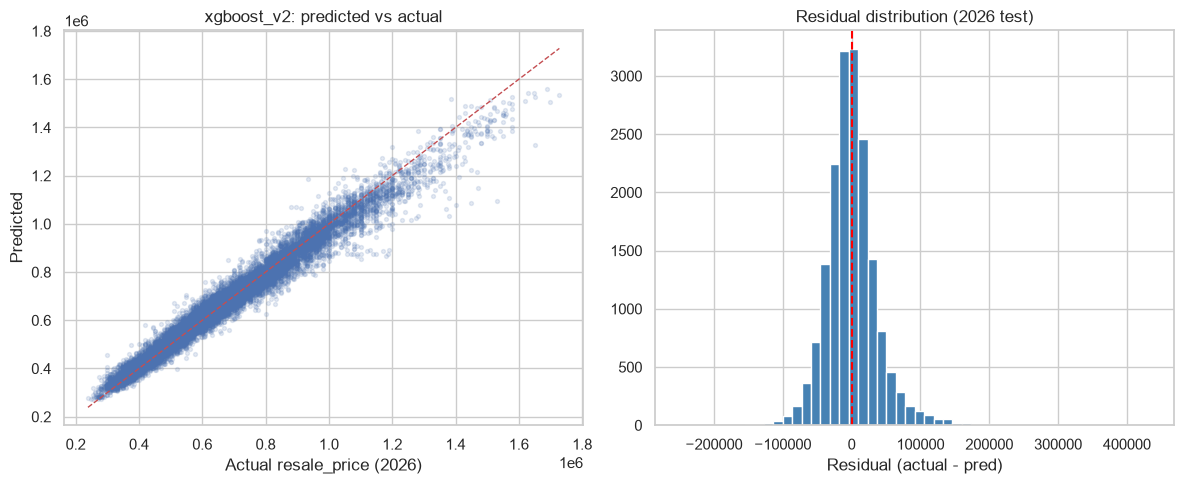

Residual MAE: 27236.5887854858
Residual median: -2175.5625


In [11]:
ok = cmp.dropna(subset = ['rmse']).sort_values('rmse')
best_name = ok.iloc[0]['model']
print('Best v2 model:', best_name)
y_pred = predict_test(best_name, X_test)
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
axes[0].scatter(y_test, y_pred, alpha = 0.15, s = 8)
mn = min(float(y_test.min()), float(y_pred.min()))
mx = max(float(y_test.max()), float(y_pred.max()))
axes[0].plot([mn, mx], [mn, mx], 'r--', lw = 1)
axes[0].set_xlabel('Actual resale_price (2026)')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_name}: predicted vs actual')
resid = np.asarray(y_test) - y_pred
axes[1].hist(resid, bins = 50, color = 'steelblue', edgecolor = 'white')
axes[1].axvline(0, color = 'red', ls = '--')
axes[1].set_xlabel('Residual (actual - pred)')
axes[1].set_title('Residual distribution (2026 test)')
fig.tight_layout()
plt.show()
print('Residual MAE:', float(np.mean(np.abs(resid))))
print('Residual median:', float(np.median(resid)))